In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
from google.colab import files

uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [3]:
df = pd.read_csv('/content/diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df['target'] = (df['readmitted'] == '<30').astype(int)
print(df['target'].value_counts())

target
0    90409
1    11357
Name: count, dtype: int64


In [5]:
features = [
    'race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3',
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'time_in_hospital', 'admission_type_id', 'admission_source_id',
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_diagnoses'
]

X = df[features]
y = df['target']

In [6]:
num_features = [
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'time_in_hospital', 'admission_type_id', 'admission_source_id',
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_diagnoses'
]

cat_features = [
    'race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3'
]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

In [9]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=1.0,
        max_iter=1000
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'time_in_hospital',
                                                   'admission_type_id',
                                                   'admission_source_id',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['race', 'gender', 'age',
                                                   'diag_1', 'diag_2',
                                                   'diag_3'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [10]:
y_prob = model.predict_proba(X_test)[:, 1]

In [11]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.6415002128377507


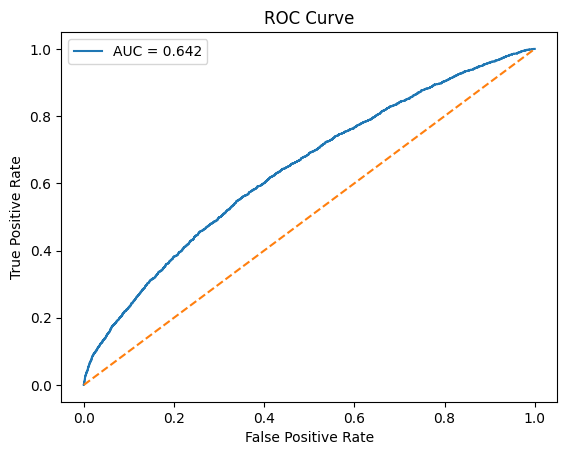

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.50      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.70      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354



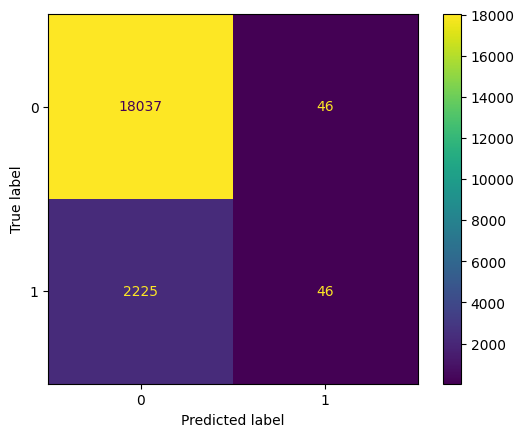

In [13]:
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()